In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

In [3]:
data1k = open('./hbase1k/hbase_load.log').read()
data10k = open('./hbase10k/hbase_load.log').read()

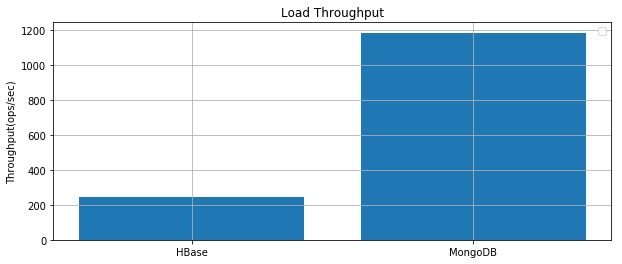

[245.15812699190977, 1186.5211200759375]

In [4]:
throughput1k = re.findall(r'^\[OVERALL\], Throughput\(ops/sec\), ([\d]+\.[\d]+)', data1k, flags=re.MULTILINE)
throughput10k = re.findall(r'^\[OVERALL\], Throughput\(ops/sec\), ([\d]+\.[\d]+)', data10k, flags=re.MULTILINE)

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

x = [0, 1]
y = [float(throughput1k[0]), float(throughput10k[0])]
xlabels = ['HBase', 'MongoDB']
ax.bar(x, y, tick_label=xlabels)

ax.set_title('Load Throughput')
ax.set_ylabel('Throughput(ops/sec)')

ax.legend()

plt.grid()

plt.show()
y

In [5]:
data500k4t = open('./hbase500k4t/hbase_load.log').read()
data500k6t = open('./hbase500k6t/hbase_load.log').read()

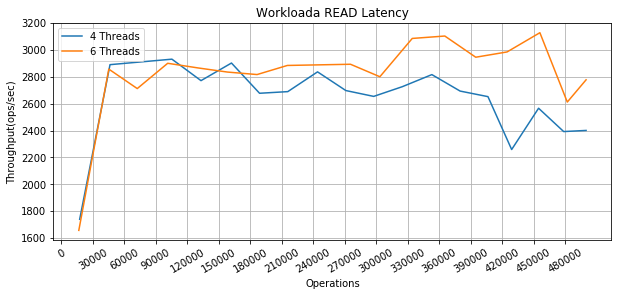

In [6]:
log4t = re.findall(r'([\d]+) operations; ([\d]+\.[\d]+) current ops/sec; ', data500k4t, flags=re.MULTILINE)
log6t = re.findall(r'([\d]+) operations; ([\d]+\.[\d]+) current ops/sec; ', data500k6t, flags=re.MULTILINE)

ops4t = [float(e[0]) for e in log4t]
thr4t =  [float(e[1]) for e in log4t]
ops6t = [float(e[0]) for e in log6t]
thr6t =  [float(e[1]) for e in log6t]

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

ax.plot(ops4t, thr4t, label='4 Threads')
ax.plot(ops6t, thr6t, label='6 Threads')

ax.set_title('Workloada READ Latency')
ax.set_ylabel('Throughput(ops/sec)')
ax.set_xlabel('Operations')
plt.xticks(range(0, 500000, 30000))

for tick in ax.get_xticklabels():
    tick.set_rotation(30)
    
ax.legend()

plt.grid()

plt.show()

In [7]:
data1k = open('./hbase1k/hbase_workloada.log').read()
data10k = open('./hbase10k/hbase_workloada.log').read()

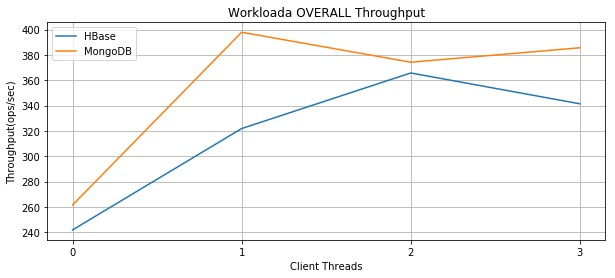

,HBase,MongoDB
0,241.779497,261.437908
1,321.853878,397.930760
2,365.764448,374.251497
3,341.413452,385.653683


In [8]:
throughput1k = re.findall(r'^\[OVERALL\], Throughput\(ops/sec\), ([\d]+\.[\d]+)', data1k, flags=re.MULTILINE)
throughput10k = re.findall(r'^\[OVERALL\], Throughput\(ops/sec\), ([\d]+\.[\d]+)', data10k, flags=re.MULTILINE)

df = pd.DataFrame({
    'HBase': [float(d) for d in throughput1k],
    'MongoDB': [float(d) for d in throughput10k]
}, index=range(len(throughput1k)))

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

ax.plot(df.index, df['HBase'], label='HBase')
ax.plot(df.index, df['MongoDB'], label='MongoDB')

ax.set_title('Workloada OVERALL Throughput')
ax.set_ylabel('Throughput(ops/sec)')
ax.set_xlabel('Client Threads')
plt.xticks(range(len(throughput1k)))

ax.legend()

plt.grid()

plt.show()
df

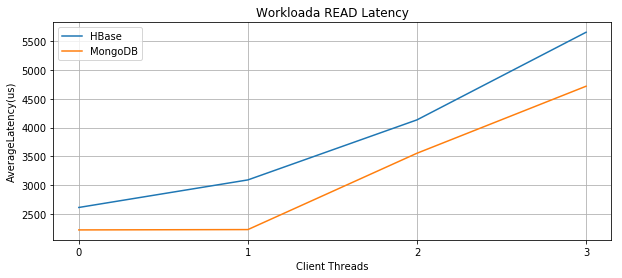

,HBase,MongoDB
0,2612.129363,2222.510557
1,3090.479769,2228.282353
2,4132.639604,3553.477642
3,5653.319846,4716.484787


In [9]:
read_latency1k = re.findall(r'^\[READ\], AverageLatency\(us\), ([\d]+\.[\d]+)', data1k, flags=re.MULTILINE)
read_latency10k = re.findall(r'^\[READ\], AverageLatency\(us\), ([\d]+\.[\d]+)', data10k, flags=re.MULTILINE)

df = pd.DataFrame({
    'HBase': [float(d) for d in read_latency1k],
    'MongoDB': [float(d) for d in read_latency10k]
}, index=range(len(read_latency1k)))

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

ax.plot(df.index, df['HBase'], label='HBase')
ax.plot(df.index, df['MongoDB'], label='MongoDB')

ax.set_title('Workloada READ Latency')
ax.set_ylabel('AverageLatency(us)')
ax.set_xlabel('Client Threads')
plt.xticks(range(len(read_latency1k)))

ax.legend()

plt.grid()

plt.show()
df

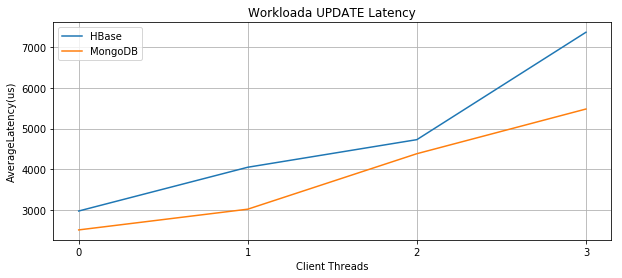

,HBase,MongoDB
0,2971.649123,2506.235908
1,4049.738046,3016.879592
2,4729.329293,4383.210630
3,7374.232848,5483.518738


In [10]:
read_latency1k = re.findall(r'^\[UPDATE\], AverageLatency\(us\), ([\d]+\.[\d]+)', data1k, flags=re.MULTILINE)
read_latency10k = re.findall(r'^\[UPDATE\], AverageLatency\(us\), ([\d]+\.[\d]+)', data10k, flags=re.MULTILINE)

df = pd.DataFrame({
    'HBase': [float(d) for d in read_latency1k],
    'MongoDB': [float(d) for d in read_latency10k]
}, index=range(len(read_latency1k)))

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

ax.plot(df.index, df['HBase'], label='HBase')
ax.plot(df.index, df['MongoDB'], label='MongoDB')

ax.set_title('Workloada UPDATE Latency')
ax.set_ylabel('AverageLatency(us)')
ax.set_xlabel('Client Threads')
plt.xticks(range(len(read_latency1k)))

ax.legend()

plt.grid()

plt.show()
df